 [1] BOOT AND MANEUVER TIMELINE
robot |  t_first[ms] |   t_last[ms] |  dur[s] |    n | state_first | state_last
----------------------------------------------------------------------------------------
    1 |         4832 |        34777 |   29.95 |  123 |           1 |          1
    2 |         8950 |        36974 |   28.02 |   44 |           1 |          1
    3 |         9311 |        39255 |   29.94 |  121 |           1 |          1
    4 |        11512 |        41519 |   30.01 |  122 |           1 |          1

  Maneuver start (local ms): {1: 4832, 2: 8950, 3: 9311, 4: 11512}
  Spread: 6680 ms

 [2] TDMA SYNC STATE
robot | frame_min frame_max | dframe/dt[Hz] | sync_lost_frac | slot_min slot_max
----------------------------------------------------------------------------------
    1 |        42       168 |         4.208 |          0.000 |        0        0
    2 |        50       168 |         4.211 |          0.000 |        0        0
    3 |        42       168 |         4.208 |

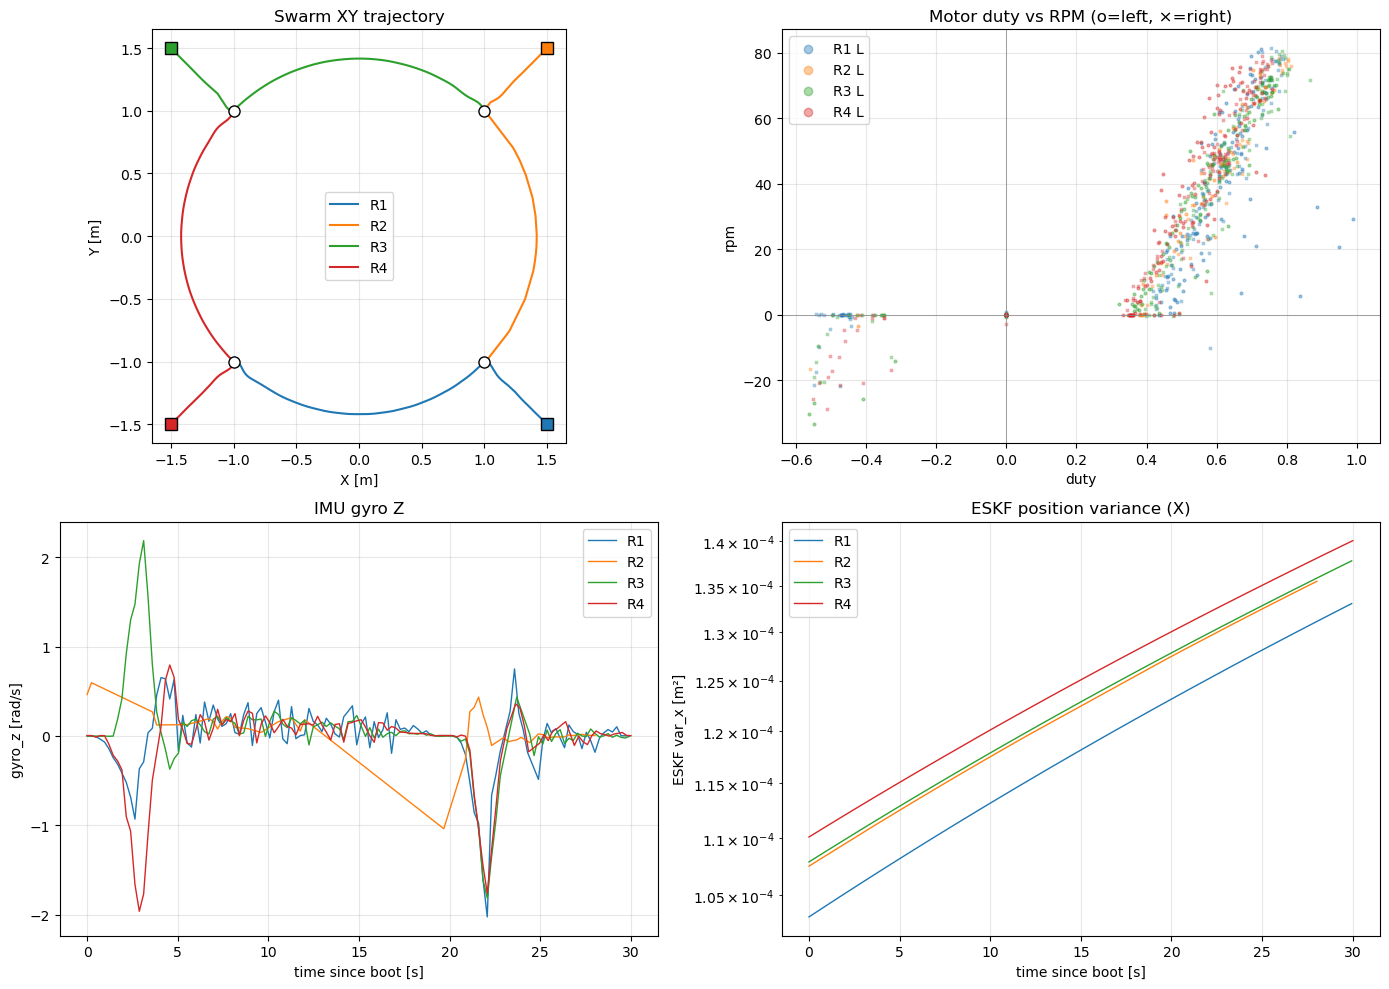

In [1]:
# ============================================================
# Comprehensive analysis — mesh TDMA v2 logs (all four robots)
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)

# ------------------------------------------------------------
# 0. Load
# ------------------------------------------------------------
FILES = {
    1: "robot_1_v2.csv",
    2: "robot_2_v2.csv",
    3: "robot_3_v2.csv",
    4: "robot_4_v2.csv",
}

data = {}
for rb, fname in FILES.items():
    p = Path(fname)
    if p.exists():
        data[rb] = pd.read_csv(p)

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
WHEEL_RADIUS_M = 0.026850
RAD_S_TO_RPM   = 60.0 / (2.0 * np.pi)
TRACK_WIDTH = {1: 0.1237, 2: 0.1248, 3: 0.1163, 4: 0.1209}

L_INITIAL     = 2.0
L_FINAL       = 3.0
ROT_FINAL_RAD = np.pi / 2
T1_ROT_SEC    = 20.0
T2_SCALE_SEC  = 10.0
T_TOTAL_SEC   = T1_ROT_SEC + T2_SCALE_SEC

UNIT_OFFSET = {
    1: (-0.5, -0.5),
    2: (+0.5, -0.5),
    3: (+0.5, +0.5),
    4: (-0.5, +0.5),
}

def quintic(s):
    return 10*s**3 - 15*s**4 + 6*s**5

def ref_pose(rb, t_elapsed):
    if t_elapsed < T1_ROT_SEC:
        tau = t_elapsed / T1_ROT_SEC
        s = quintic(max(0.0, min(1.0, tau)))
        phi = ROT_FINAL_RAD * s
        L = L_INITIAL
    elif t_elapsed < T_TOTAL_SEC:
        tau = (t_elapsed - T1_ROT_SEC) / T2_SCALE_SEC
        s = quintic(max(0.0, min(1.0, tau)))
        phi = ROT_FINAL_RAD
        L = L_INITIAL + (L_FINAL - L_INITIAL) * s
    else:
        phi = ROT_FINAL_RAD
        L = L_FINAL
    rx, ry = UNIT_OFFSET[rb]
    c, s_ = np.cos(phi), np.sin(phi)
    return c * L * rx - s_ * L * ry, s_ * L * rx + c * L * ry, phi

# ============================================================
# [1] BOOT / MANEUVER TIMELINE
# ============================================================
print("=" * 100)
print(" [1] BOOT AND MANEUVER TIMELINE")
print("=" * 100)
print(f"{'robot':>5s} | {'t_first[ms]':>12s} | {'t_last[ms]':>12s} | "
      f"{'dur[s]':>7s} | {'n':>4s} | "
      f"{'state_first':>11s} | {'state_last':>10s}")
print("-" * 88)

maneuver_start = {}
for rb, d in data.items():
    t0 = int(d["t_ms"].iloc[0])
    t1 = int(d["t_ms"].iloc[-1])
    dur = (t1 - t0) / 1000.0
    rs0 = int(d["robot_state"].iloc[0]) if "robot_state" in d.columns else -1
    rs1 = int(d["robot_state"].iloc[-1]) if "robot_state" in d.columns else -1

    # find first sample with state==1
    if "robot_state" in d.columns:
        first_run = np.where(d["robot_state"].values == 1)[0]
        maneuver_start[rb] = d["t_ms"].iloc[first_run[0]] if len(first_run) else -1
    else:
        maneuver_start[rb] = -1

    print(f"{rb:>5d} | {t0:>12d} | {t1:>12d} | "
          f"{dur:>7.2f} | {len(d):>4d} | "
          f"{rs0:>11d} | {rs1:>10d}")

print(f"\n  Maneuver start (local ms): "
      f"{ {rb: maneuver_start[rb] for rb in sorted(data)} }")
print(f"  Spread: "
      f"{max(maneuver_start.values()) - min(maneuver_start.values())} ms")

# ============================================================
# [2] TDMA SYNC STATE
# ============================================================
print("\n" + "=" * 100)
print(" [2] TDMA SYNC STATE")
print("=" * 100)
print(f"{'robot':>5s} | {'frame_min':>9s} {'frame_max':>9s} | "
      f"{'dframe/dt[Hz]':>13s} | {'sync_lost_frac':>14s} | "
      f"{'slot_min':>8s} {'slot_max':>8s}")
print("-" * 82)

for rb, d in data.items():
    if "tdma_frame_id" not in d.columns: continue
    span_s = (d["t_ms"].iloc[-1] - d["t_ms"].iloc[0]) / 1000.0
    dfr = d["tdma_frame_id"].iloc[-1] - d["tdma_frame_id"].iloc[0]
    rate = dfr / span_s if span_s > 0 else 0
    sl_frac = d["tdma_sync_lost"].mean()
    print(f"{rb:>5d} | "
          f"{int(d['tdma_frame_id'].min()):>9d} "
          f"{int(d['tdma_frame_id'].max()):>9d} | "
          f"{rate:>13.3f} | {sl_frac:>14.3f} | "
          f"{int(d['tdma_slot_index'].min()):>8d} "
          f"{int(d['tdma_slot_index'].max()):>8d}")

# ============================================================
# [3] SLOT VISITING PATTERN
# ============================================================
print("\n" + "=" * 100)
print(" [3] SLOT VISITING PATTERN  (should be uniform across 0..15)")
print("=" * 100)
print(f"\n{'robot':>5s} | " +
      " ".join(f"s{s:>2d}" for s in range(16)))
print("-" * 84)

for rb, d in data.items():
    if "tdma_slot_index" not in d.columns: continue
    counts = d["tdma_slot_index"].value_counts().to_dict()
    row = f"{rb:>5d} | "
    cells = [f"{counts.get(s, 0):>3d}" for s in range(16)]
    print(row + " ".join(cells))

# ============================================================
# [4] UWB DATA PRESENCE
# ============================================================
print("\n" + "=" * 100)
print(" [4] UWB DATA PRESENCE")
print("=" * 100)
print(f"{'robot':>5s} | " +
      " | ".join(f"uwb{i}_raw nonzero" for i in (1, 2, 3)))
print("-" * 56)
for rb, d in data.items():
    row = f"{rb:>5d} | "
    cells = []
    for i in (1, 2, 3):
        col = f"uwb{i}_raw"
        if col in d.columns:
            nz = int((d[col].abs() > 1e-6).sum())
            cells.append(f"{nz:>16d}")
        else:
            cells.append(f"{'--':>16s}")
    print(row + " | ".join(cells))

# ============================================================
# [5] UWB PEER IDs AND QUALITY
# ============================================================
print("\n" + "=" * 100)
print(" [5] UWB PEER IDs AND SIGNAL QUALITY  (nonzero samples only)")
print("=" * 100)

for rb, d in data.items():
    print(f"\n  R{rb}:")
    for i in (1, 2, 3):
        raw_col = f"uwb{i}_raw"
        if raw_col not in d.columns: continue
        mask = d[raw_col].abs() > 1e-6
        sub = d[mask]
        if len(sub) == 0:
            print(f"    uwb{i}: 0 valid samples")
            continue
        peer_ids = sub[f"uwb{i}_peer_id"].unique()
        rssi_mean = sub[f"uwb{i}_rssi"].mean()
        raw_mean = sub[raw_col].mean()
        clean_mean = sub[f"uwb{i}_clean"].mean()
        noise_mean = sub[f"uwb{i}_std_noise"].mean()
        print(f"    uwb{i}: n={len(sub):>3d}, peer_ids={list(peer_ids)}, "
              f"raw_mean={raw_mean:+.3f}, clean_mean={clean_mean:+.3f}, "
              f"rssi_mean={rssi_mean:+.1f}, noise_mean={noise_mean:.0f}")

# ============================================================
# [6] MOTOR CALIBRATION PER ROBOT (running slice only)
# ============================================================
print("\n" + "=" * 100)
print(" [6] MOTOR CALIBRATION  (running samples only)")
print("=" * 100)
print(f"{'robot':>5s} | {'side':>3s} | {'n':>4s} | "
      f"{'db':>7s} | {'gain':>8s} | "
      f"{'rmse_rpm':>9s} | {'sat_frac':>9s}")
print("-" * 70)

for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    dr = d[d["robot_state"] == 1]
    if len(dr) < 20: continue

    for side, duty_col, rpm_col in [("L", "duty_l", "rpm_l"),
                                     ("R", "duty_r", "rpm_r")]:
        duty = dr[duty_col].values
        rpm  = dr[rpm_col].values

        # deadband: lowest duty at which |rpm| > 5
        mf = (duty > 0.05) & (rpm > 5.0)
        if mf.sum() > 10:
            db = float(duty[mf].min())
            A = np.vstack([duty[mf] - db, np.ones(mf.sum())]).T
            coef, *_ = np.linalg.lstsq(A, rpm[mf], rcond=None)
            gain = float(coef[0])
        else:
            db, gain = np.nan, np.nan

        # tracking error
        if "target_rpm_l" in dr.columns:
            tgt_col = "target_rpm_l" if side == "L" else "target_rpm_r"
            err = dr[tgt_col].values - rpm
            rmse = float(np.sqrt(np.mean(err**2)))
        else:
            rmse = np.nan

        sat = float(np.mean(np.abs(duty) > 0.95))

        print(f"{rb:>5d} | {side:>3s} | {len(dr):>4d} | "
              f"{db:>7.4f} | {gain:>8.2f} | "
              f"{rmse:>9.3f} | {sat:>9.3f}")

# ============================================================
# [7] IMU GYRO vs WHEEL-DERIVED OMEGA
# ============================================================
print("\n" + "=" * 100)
print(" [7] IMU GYRO vs WHEEL-DERIVED OMEGA  (running samples)")
print("=" * 100)
print(f"{'robot':>5s} | {'n':>4s} | {'corr':>6s} | "
      f"{'res_mean':>9s} | {'res_std':>8s} | "
      f"{'gyro_bias_est':>14s}")
print("-" * 72)

for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    dr = d[d["robot_state"] == 1]
    if len(dr) < 20: continue

    rl = dr["rpm_l"].values
    rr = dr["rpm_r"].values
    omega_wheel = (rr - rl) * (2.0 * np.pi / 60.0) * WHEEL_RADIUS_M / TRACK_WIDTH[rb]
    gyro = dr["gyro_z"].values

    res = gyro - omega_wheel
    corr = float(np.corrcoef(gyro, omega_wheel)[0, 1]) if len(gyro) > 2 else np.nan

    print(f"{rb:>5d} | {len(dr):>4d} | {corr:>6.3f} | "
          f"{res.mean():>+9.4f} | {res.std():>8.4f} | "
          f"{res.mean():>+14.4f}")

# ============================================================
# [8] ESKF COVARIANCE EVOLUTION
# ============================================================
print("\n" + "=" * 100)
print(" [8] ESKF COVARIANCE EVOLUTION")
print("=" * 100)
print(f"{'robot':>5s} | "
      f"{'var_x: start → end':>25s} | "
      f"{'var_theta: start → end':>25s} | "
      f"{'var_bias: start → end':>25s}")
print("-" * 92)
for rb, d in data.items():
    if "eskf_var_x" not in d.columns: continue
    vx0, vx1 = d["eskf_var_x"].iloc[0], d["eskf_var_x"].iloc[-1]
    vt0, vt1 = d["eskf_var_theta"].iloc[0], d["eskf_var_theta"].iloc[-1]
    vb0, vb1 = d["eskf_var_bias"].iloc[0], d["eskf_var_bias"].iloc[-1]
    print(f"{rb:>5d} | "
          f"{vx0:.3e} → {vx1:.3e} | "
          f"{vt0:.3e} → {vt1:.3e} | "
          f"{vb0:.3e} → {vb1:.3e}")

# ============================================================
# [9] TRAJECTORY TRACKING
# ============================================================
print("\n" + "=" * 100)
print(" [9] TRAJECTORY TRACKING")
print("=" * 100)

for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    dr = d[d["robot_state"] == 1]
    if len(dr) < 10: continue

    # Anchor: robot's own first running sample
    t0_own = dr["t_ms"].iloc[0]
    errs = []
    head_errs = []
    for _, row in dr.iterrows():
        te = (row["t_ms"] - t0_own) / 1000.0
        if te < 0 or te > T_TOTAL_SEC + 3:
            continue
        xr, yr, phir = ref_pose(rb, te)
        errs.append(np.hypot(row["x"] - xr, row["y"] - yr))
        he = row["heading"] - phir
        while he >  np.pi: he -= 2*np.pi
        while he < -np.pi: he += 2*np.pi
        head_errs.append(he)

    if not errs: continue
    errs = np.array(errs) * 100
    head_errs = np.degrees(np.array(head_errs))

    print(f"  R{rb}: n={len(errs):>3d}, "
          f"err_mean={errs.mean():>6.2f} cm, "
          f"err_max={errs.max():>6.2f} cm, "
          f"err_final={errs[-1]:>6.2f} cm, "
          f"head_err_mean={head_errs.mean():>+6.2f}°")

# ============================================================
# [10] BOOT TIME SPREAD AND MANEUVER START SPREAD
# ============================================================
print("\n" + "=" * 100)
print(" [10] TIMING CONSISTENCY")
print("=" * 100)
t_first_all = {rb: int(d["t_ms"].iloc[0]) for rb, d in data.items()}
mstart_all  = {rb: maneuver_start[rb] for rb in maneuver_start if maneuver_start[rb] > 0}

print(f"  Boot times (ms): {t_first_all}")
print(f"  Boot spread:     "
      f"{max(t_first_all.values()) - min(t_first_all.values())} ms")
print(f"  Maneuver start:  {mstart_all}")
if len(mstart_all) >= 2:
    print(f"  Maneuver spread: "
          f"{max(mstart_all.values()) - min(mstart_all.values())} ms")

# ============================================================
# [11] PLOT — swarm trajectory + per-robot diagnostics
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {1: "tab:blue", 2: "tab:orange", 3: "tab:green", 4: "tab:red"}

# (a) XY trajectory
ax = axes[0, 0]
for rb, d in data.items():
    ax.plot(d["x"], d["y"], color=colors[rb], lw=1.5, label=f"R{rb}")
for rb in (1, 2, 3, 4):
    rx, ry = UNIT_OFFSET[rb]
    xi, yi = L_INITIAL * rx, L_INITIAL * ry
    c, s = np.cos(ROT_FINAL_RAD), np.sin(ROT_FINAL_RAD)
    xf = c * L_FINAL * rx - s * L_FINAL * ry
    yf = s * L_FINAL * rx + c * L_FINAL * ry
    ax.plot(xi, yi, "o", color=colors[rb], ms=8,
            markeredgecolor="black", markerfacecolor="white")
    ax.plot(xf, yf, "s", color=colors[rb], ms=8, markeredgecolor="black")
ax.set_aspect("equal")
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")
ax.set_title("Swarm XY trajectory")
ax.legend(); ax.grid(True, alpha=0.3)

# (b) duty vs rpm
ax = axes[0, 1]
for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    dr = d[d["robot_state"] == 1]
    if len(dr) == 0: continue
    ax.scatter(dr["duty_l"], dr["rpm_l"], s=4, alpha=0.4,
               color=colors[rb], label=f"R{rb} L")
    ax.scatter(dr["duty_r"], dr["rpm_r"], s=4, alpha=0.4,
               color=colors[rb], marker="x")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("duty"); ax.set_ylabel("rpm")
ax.set_title("Motor duty vs RPM (o=left, ×=right)")
ax.legend(markerscale=3); ax.grid(True, alpha=0.3)

# (c) gyro_z over time
ax = axes[1, 0]
for rb, d in data.items():
    t_rel = (d["t_ms"] - d["t_ms"].iloc[0]) / 1000.0
    ax.plot(t_rel, d["gyro_z"], color=colors[rb], lw=1.0, label=f"R{rb}")
ax.set_xlabel("time since boot [s]")
ax.set_ylabel("gyro_z [rad/s]")
ax.set_title("IMU gyro Z")
ax.legend(); ax.grid(True, alpha=0.3)

# (d) ESKF var_x over time
ax = axes[1, 1]
for rb, d in data.items():
    if "eskf_var_x" not in d.columns: continue
    t_rel = (d["t_ms"] - d["t_ms"].iloc[0]) / 1000.0
    ax.plot(t_rel, d["eskf_var_x"], color=colors[rb], lw=1.0, label=f"R{rb}")
ax.set_xlabel("time since boot [s]")
ax.set_ylabel("ESKF var_x [m²]")
ax.set_title("ESKF position variance (X)")
ax.set_yscale("log")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comprehensive_v2_analysis.png", dpi=120)
plt.show()